In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist as mnist_keras
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D

import joblib

(70000, 784)
(70000,)
På bilden visas en datapunkt med label:  5


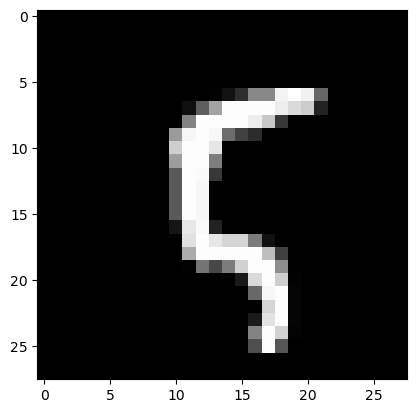

In [ ]:
mnist = fetch_openml(name='mnist_784', cache=True, as_frame=False)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)
                                   
print(X.shape)
print(y.shape)



På bilden visas en datapunkt med label:  5


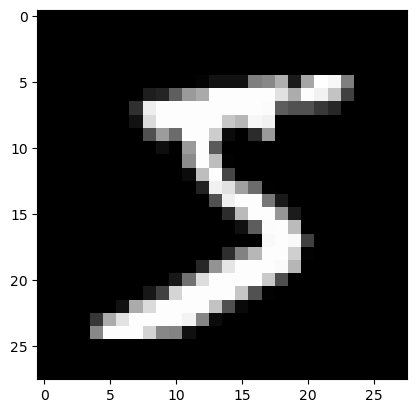

In [83]:

some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap="gray")
print("På bilden visas en datapunkt med label: ", y[0])

In [ ]:
X[0][:200] # visar de första 200 pixlarna i den första datapunkten

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

Det är ett rimligt antagande att fördeleningen mellan siffrorna i MNIST jämn.
För att bekräfta detta kan vi titta på fördelningen av klasser (d.v.s möjliga värden på y) i datasetet:


<Axes: >

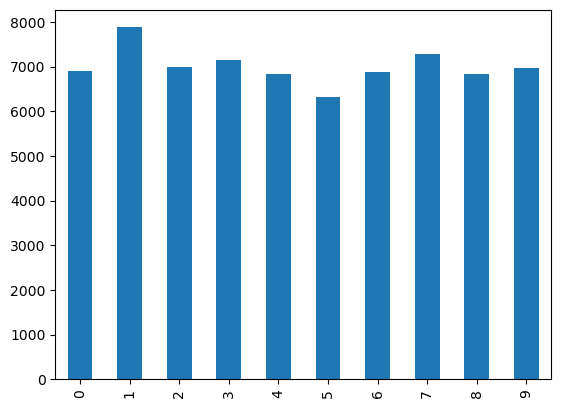

In [ ]:
print("Det är ett rimligt antagande att fördeleningen mellan siffrorna i MNIST jämn.")
print("För att bekräfta detta kan vi titta på fördelningen av klasser:")

val_counts = pd.Series(y).value_counts()
val_counts.sort_index(inplace=True)
val_counts.plot(kind='bar')

### Datan 

MNIST är et set med handskriva siffror. Det finns ***70000*** datapunkter i träningsdatan där ***10000*** är avsedda för test. Jag har valt att dela upp datan i ***50000*** för träning, ***10000*** för validering och ***10000*** för test. Test och valideringsetsen används i kombination i det fall jag använder cross_validate.

Stapeldiagrammet ovan visar att datasetet är balanserat mellan klasserna. 

Verje bild är 28x28px stor. Siffran sparas som en array av pixlar där varje pixel är en feature. Varje bild har därför ***784 features*** + en label som håller informationen om vilken siffra bilden representerar (y). Vi kan även se att siffran är i gråskala och att färgerna är inverterade. Bakgrunden är alltså svart (reprepseneras av värdet 0 i matrisen) medan själva siffran är grå eller vit (> 1 <= 255). 

### Val av modell
En av det första frågorna jag ställde mig var om MNIST var linjärt separerbart och om jag kunde testa det. Eftersom datasetet är högdimensionellt så är det inte enkelt att se. Jag valde därför att använda ***Logistisk Regression*** för att ha en bas att jämföra de andra modellernas prestanda mot.
De primära modellerna jag ville utvärdera var ***SVM*** och en ensamle modell som ***RandomForest*** eller ***ExtraTrees***. 
Slutligen ville jag även utvärdera en DL modell för att se hur den presetrar mot de traditionella ML modellerna. Jag valde ***CNN*** för detta.    

### Val av utvärderingsmått

Eftersom MNIST är ett klassifieringsproblem så behöver man förhålla sig till vilket utvärderingsmått som är rimligt för datan. I fallet MNIST så har vi sett att det är jämnt fördelat mellan klasserna. Vi kan också anta att en siffra inte är viktigare än en annan. Med det i åtanke så har jag valt ***accuracy*** under modellutvärderingen.

Mot slutet av utvärderingen så har jag även använt mig av mig av ***Confusion Matrix*** för att få en bild av hur modellen presterar på olika klasser, samt ***classification resport***.     

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, 
                                                            test_size=10000, 
                                                            random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, 
                                                  test_size=10000, 
                                                  random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)

X_train_val = scaler.transform(X_train_val)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
"""
Logistisk regression. 
Korsvalidering av hyperparemetern C (regulariseringsstyrka).

"""

log_reg = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1],
    max_iter=500, 
    random_state=42)

log_reg.fit(X_train, y_train)

log_reg_val_pred = log_reg.predict(X_val)

log_reg_accuracy = accuracy_score(y_val, log_reg_val_pred)
print("Logistisk regression accuracy score:", log_reg_accuracy)
print("Optimalt värde på C (regulariseringsstyrka)för varje klass: ", log_reg.C_)

Logistisk regression accuracy score: 0.9221
Värde på C (regulariseringsstyrka):  [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


###SVM

För klassiiceringsproblem har scikit learn två SVM modeller: SVC och LinearSVC. Enligt dokumentationen är LinearSVC mer flexibel när det kommer till penalties och skall skala bättre för större datasets. Dock använder den alltid linear som kernel. Eftersom vi inte vet om vårat dataset är linjärt så har jag använt mig av ***SVC***.

SVM är en modell som rekommenderas för små eller mellanstora datasets. Enligt dokumentationen kan SVC vara opålitligt på datasets med mer än tiotusentals datapunker. Vårt dataset borde inte vara för stort. SVM är även långsamt att träna. Jag har därför valt att tuna hyperparametrarna på ett subset av 10000 poster och tre "folds" (iterationer per set av parametrar). Jag har valt att tuna variablerna ***C*** och ***kernel***. Med verbositeten satt till 2 kan man se hur lång tid varje fit tar. 

Jag har även tunat gamma variablen för den bästa kerneln (rbf) innan jag gjort en cross_validation för att utvärdera modellen.

In [38]:

X_train_subset = X_train[:10000]
y_train_subset = y_train[:10000]

In [ ]:

svc_grid = GridSearchCV(SVC(), param_grid={
    'C': [0.001, 0.01, 0.1, 1], 
    'kernel' : ['rbf', 'linear', 'poly']}, cv=3, verbose=1)

svc_grid.fit(X_train_subset, y_train_subset)
svc_grid_val_pred = svc_grid.predict(X_val)

svc_grid_accuracy = accuracy_score(y_val, svc_grid_val_pred)
print("SVC accuracy score:", svc_grid_accuracy)
print("Bästa parametrar för SVC:", svc_grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ................................C=0.001, kernel=rbf; total time=  26.9s
[CV] END ................................C=0.001, kernel=rbf; total time=  27.0s
[CV] END ................................C=0.001, kernel=rbf; total time=  26.7s
[CV] END .............................C=0.001, kernel=linear; total time=   5.6s
[CV] END .............................C=0.001, kernel=linear; total time=   5.3s
[CV] END .............................C=0.001, kernel=linear; total time=   5.5s
[CV] END ...............................C=0.001, kernel=poly; total time=  22.6s
[CV] END ...............................C=0.001, kernel=poly; total time=  22.1s
[CV] END ...............................C=0.001, kernel=poly; total time=  22.5s
[CV] END .................................C=0.01, kernel=rbf; total time=  27.6s
[CV] END .................................C=0.01, kernel=rbf; total time=  26.3s
[CV] END .................................C=0.01

In [ ]:
#fit the whole set with the best parameters
svc1 = SVC(C=1, #svc_grid.best_params_['C'], 
    kernel="rbf" #svc_grid.best_params_['kernel']
)

svc_gs_rbf=GridSearchCV(svc1, param_grid={
    'gamma': [0.001, 0.01, 0.1, 1]}, cv=5, verbose=1)
svc_gs_rbf.fit(X_train_subset, y_train_subset)

svc_gs_rbf_val = svc_gs_rbf.predict(X_val)
svc_gs_rbf_accuracy = accuracy_score(y_val, svc_gs_rbf_val)
print("SVC accuracy score:", svc_gs_rbf_accuracy)
print("Bästa gamma för SVC med RBF-kernel:", svc_gs_rbf.best_params_['gamma'])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ........................................gamma=0.001; total time=  11.3s
[CV] END ........................................gamma=0.001; total time=  10.8s
[CV] END ........................................gamma=0.001; total time=   9.9s
[CV] END ........................................gamma=0.001; total time=   9.7s
[CV] END ........................................gamma=0.001; total time=   9.4s
[CV] END .........................................gamma=0.01; total time=  33.8s
[CV] END .........................................gamma=0.01; total time=  34.7s
[CV] END .........................................gamma=0.01; total time=  33.5s
[CV] END .........................................gamma=0.01; total time=  31.8s
[CV] END .........................................gamma=0.01; total time=  32.3s
[CV] END ..........................................gamma=0.1; total time=  38.2s
[CV] END ........................................

In [49]:
#fit the whole set with the best parameters
svc_cv = SVC(C=1, #svc_grid.best_params_['C'], 
    kernel="rbf", #svc_grid.best_params_['kernel'], 
    gamma=0.001) #svc_gs_rbf.best_params_['gamma'])


cross_val_scores = cross_validate(
    svc_cv, 
    X_train_val, 
    y_train_val, 
    cv=5, 
    return_train_score=True, 
    scoring='accuracy', 
    verbose=2)

print(cross_val_scores['test_score'])
print("SVC accuracy score mean:", cross_val_scores['test_score'].mean())

[CV] END .................................................... total time= 5.3min
[CV] END .................................................... total time= 5.2min
[CV] END .................................................... total time= 6.1min
[CV] END .................................................... total time= 5.0min
[CV] END .................................................... total time= 6.0min
[0.961      0.96283333 0.96066667 0.96325    0.96091667]
SVC accuracy score mean: 0.9617333333333333


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 58.4min finished


In [54]:
print(f"Mean fit time: {cross_val_scores['fit_time'].mean():.0f} seconds")
print(f"Mean score time: {cross_val_scores['score_time'].mean():.0f} seconds")

Mean fit time: 243 seconds
Mean score time: 88 seconds


### Decision Trees

För decision tree så har jag valt att fokusera på ensable modellerna Random Forest och Extra Trees.
Jag gör en grid search för att tuna hyperparametrar och sedan en cross_validation på test och träningsseten med de tunade parametrarna.

In [ ]:
rf = RandomForestClassifier(random_state=42,
                            max_features='sqrt')

rf_grid_search = GridSearchCV(rf, param_grid={
    'n_estimators': [200, 400],
    'max_depth': [10, 30, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]}) #verbose=2) - tar ca 30-60 minuter att köra

rf_grid_search.fit(X_train_subset, y_train_subset)

rf_val_pred = rf_grid_search.predict(X_val)
rf_val_accuracy = accuracy_score(y_val, rf_val_pred)

print("Random Forest accuracy score:", rf_val_accuracy)
print("Bästa parametrar för Random Forest:", rf_grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   5.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   5.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   5.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   6.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   5.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=  10.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=  10.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=  10.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=400; total time=  10.7s
[CV] END max_depth=10, min_sa

In [ ]:
rf2 = RandomForestClassifier(random_state=42,
                            max_features='sqrt',
                            max_depth = rf_grid_search.best_params_['max_depth'],
                            min_samples_split=rf_grid_search.best_params_['min_samples_split'],
                            min_samples_leaf=rf_grid_search.best_params_['min_samples_leaf'],
                            n_estimators=rf_grid_search.best_params_['n_estimators'])

rf_cv_scores = cross_validate(
    rf2, 
    X_train_val, 
    y_train_val, 
    cv=5,
    return_train_score=True,
    scoring='accuracy') # ,verbose=2) - tar ca 10 minnuter att köra

print(rf_cv_scores['test_score'])
print(f"Random Forest accuracy score mean: {rf_cv_scores['test_score'].mean():.4f}")

[0.96666667 0.9685     0.971      0.96866667 0.96758333]
Random Forest accuracy score mean: 0.9685


In [55]:
print(f"Mean fit time: {rf_cv_scores['fit_time'].mean():.0f} seconds")
print(f"Mean score time: {rf_cv_scores['score_time'].mean():.0f} seconds")

Mean fit time: 103 seconds
Mean score time: 2 seconds


In [ ]:
et1 = ExtraTreesClassifier(random_state=42, n_jobs=5)

et_gs = GridSearchCV(et1, 
                     param_grid={
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_depth': [10, 30, 100, None],
    'n_estimators': [200, 400]}) #,verbose=2) - tar ca 10 minuter att köra

et_gs.fit(X_train_subset, y_train_subset)
et_gs_val_pred = et_gs.predict(X_val)
et_gs_val_accuracy = accuracy_score(y_val, et_gs_val_pred)
print("Extra Trees accuracy score:", et_gs_val_accuracy)
print("Bästa parametrar för Extra Trees:", et_gs.best_params_) 

print("Bästa parametrar vid körning av koden ovan:")
print("{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=200; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=200; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=200; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=200; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=200; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=400; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=400; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=400; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=1, n_estimators=400; total time=   0.0s
[CV] END max_depth=10, min_sa

c:\Users\PC\anaconda3\envs\yh\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
120 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\PC\anaconda3\envs\yh\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\PC\anaconda3\envs\yh\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\PC\anaconda3\envs\yh\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\PC\anaconda

Extra Trees accuracy score: 0.957
Bästa parametrar för Extra Trees: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Bästa parametrar vid körning av koden ovan:
{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [42]:
et = ExtraTreesClassifier(
    n_estimators=400,
    n_jobs=4,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1)
    
#et = ExtraTreesClassifier(n_estimators=400, random_state=8, n_jobs=4)
et_cross_val_scores = cross_validate(
    et, 
    X_train_val, 
    y_train_val, 
    cv=5, 
    return_train_score=True, 
    scoring='accuracy', 
    verbose=2)

print(et_cross_val_scores['test_score'])
print(f"Extra Trees accuracy score mean: {et_cross_val_scores['test_score'].mean():.4f}")

[CV] END .................................................... total time=  29.1s
[CV] END .................................................... total time=  28.1s
[CV] END .................................................... total time=  35.2s
[CV] END .................................................... total time=  40.8s
[CV] END .................................................... total time=  28.7s
[0.97175    0.97241667 0.97341667 0.97266667 0.97141667]
Extra Trees accuracy score mean: 0.9723


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.9min finished


In [ ]:
print(f"Mean fit time: {et_cross_val_scores['fit_time'].mean():.0f} seconds")
print(f"Mean score time: {et_cross_val_scores['score_time'].mean():.0f} seconds")

Mean fit time: 32 seconds
Mean score time: 1 seconds
{'fit_time': array([28.60825706, 27.58890986, 34.48243594, 40.39003897, 28.29533553]), 'score_time': array([0.59207511, 0.59291816, 0.80297494, 0.53123951, 0.53879166]), 'test_score': array([0.97175   , 0.97241667, 0.97341667, 0.97266667, 0.97141667]), 'train_score': array([1., 1., 1., 1., 1.])}


### Utvärdering av klassiska modeller

Accuracy för en vända med LogisticalRegressionCV var accuracy 0.9221. Här är siffrorna för de andra klassiska modellerna efter en 5-fold cross validering med träning -och valideringsdata:

| Modell | Mean cccuracy | Mean fit time (s) | Mean score time (s) |
| ----------- | ----------- | ----------- | ----------- |
| SVC | 0.9617 | 243 | 88 |
| Random Forest | 0.971 | 103 | 2 |
| Extra Trees | 0.9723 | 32 | 1 |

Extra Trees presterar bäst.

### CNN

Extra Trees är den som presterar bäst av de klassiska modellerna i mina test. Innan jag går vidare vill jag även utvärdera en DL modell. Jag har valt att använda mig av CNN.

Tensorflow/keras har en version av MNIST som är i rätt format, så för enkelhetens skull kommer jag att läsa in det. Jag skriver även ut en bild för att visa att det är samma dataset.  

Min CNN modell har 4 convolution layers. Jag har inte tunat hyperparametrarna. 

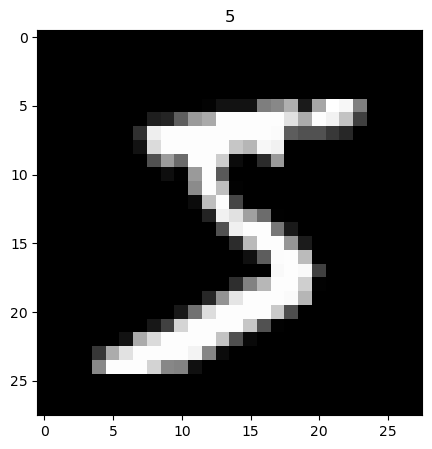

In [ ]:
#Load MNIST from keras

(X_train_cnn, y_train_cnn), (X_test_cnn, y_test_cnn)  = mnist_keras.load_data()

print("X_train_cnn shape:", X_train_cnn.shape)
print("y_train_cnn shape:", y_train_cnn.shape)

# Normalize data
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# Show the first image
plt.figure(figsize=(5,5))
plt.imshow(X_train_cnn[0], cmap='gray')
plt.title(y_train_cnn[0])
plt.show()


In [27]:
cnn = Sequential()
cnn.add(Input(shape=(28, 28, 1)))
cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dropout(0.5))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dense(10, activation='softmax'))

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = cnn.fit(
    X_train_cnn, 
    y_train_cnn, 
    epochs=10, 
    batch_size=64, 
    verbose=2, 
    validation_split=0.1)

Epoch 1/10
844/844 - 13s - 16ms/step - accuracy: 0.9204 - loss: 0.2488 - val_accuracy: 0.9858 - val_loss: 0.0497
Epoch 2/10
844/844 - 11s - 13ms/step - accuracy: 0.9797 - loss: 0.0708 - val_accuracy: 0.9897 - val_loss: 0.0368
Epoch 3/10
844/844 - 11s - 13ms/step - accuracy: 0.9846 - loss: 0.0500 - val_accuracy: 0.9913 - val_loss: 0.0256
Epoch 4/10
844/844 - 11s - 13ms/step - accuracy: 0.9880 - loss: 0.0398 - val_accuracy: 0.9905 - val_loss: 0.0320
Epoch 5/10
844/844 - 11s - 13ms/step - accuracy: 0.9904 - loss: 0.0328 - val_accuracy: 0.9932 - val_loss: 0.0302
Epoch 6/10
844/844 - 11s - 13ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.9922 - val_loss: 0.0322
Epoch 7/10
844/844 - 11s - 13ms/step - accuracy: 0.9923 - loss: 0.0255 - val_accuracy: 0.9935 - val_loss: 0.0282
Epoch 8/10
844/844 - 12s - 14ms/step - accuracy: 0.9930 - loss: 0.0226 - val_accuracy: 0.9925 - val_loss: 0.0356
Epoch 9/10
844/844 - 12s - 14ms/step - accuracy: 0.9946 - loss: 0.0187 - val_accuracy: 0.9940 - 

### Utvädering av modeller

Jag har valt att gå vidare med Extra Trees och CNN. Nästa steg är att utvärdera dem mot testdatan. I utvärderingan använder jag mig av Confusion Matrix och Classification Report. Generellt har Extra Trees en accuracy på ungefär 97% mot testdatan och CNN runt 99%. Den är möjligen något lägre än på träning/validering setet, men inte markant. Vi kan se att den har mer problem med vissa siffror, till exempel nior.

In [64]:
cnn_test_pred = cnn.predict(X_test_cnn)
cnn_test_pred_classes = np.argmax(cnn_test_pred, axis=1)
accuracy_cnn_test = accuracy_score(y_test_cnn, cnn_test_pred_classes)

cnn_report = classification_report(y_test_cnn, cnn_test_pred_classes)
cnn_matrix = confusion_matrix(y_test_cnn, cnn_test_pred_classes)
print("Results for CNN on test data:")
print()
print("Accuracy: ", accuracy_cnn_test)
print()
print("Classification Report: ")
print(cnn_report)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Results for CNN on test data:

Accuracy:  0.9923

Classification Report: 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



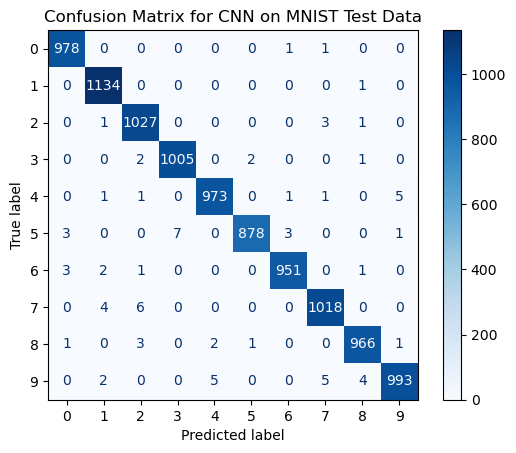

In [60]:
cnn_cm_display = ConfusionMatrixDisplay(confusion_matrix=cnn_matrix, display_labels=np.arange(10))
cnn_cm_display.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for CNN on MNIST Test Data")
plt.show()

In [65]:
#retrain extratrees on the whole training set with the best parameters and test on test data

et_train = ExtraTreesClassifier(
    n_estimators=400,
    n_jobs=4,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1)

et_train.fit(X_train_val, y_train_val)


,n_estimators,400
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [66]:
et_train_pred = et_train.predict(X_test)
et_train_accuracy = accuracy_score(y_test, et_train_pred)

et_report = classification_report(y_test, et_train_pred)
et_matrix = confusion_matrix(y_test, et_train_pred)

print("Results for Extra Trees on test data:")
print()
print("Accuracy: ", et_train_accuracy)
print()
print("Classification Report: ")
print(et_report)

Results for Extra Trees on test data:

Accuracy:  0.9704

Classification Report: 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       983
           1       0.98      0.99      0.99      1152
           2       0.95      0.97      0.96       967
           3       0.96      0.96      0.96      1034
           4       0.97      0.97      0.97       906
           5       0.98      0.97      0.97       937
           6       0.98      0.99      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.95      0.96      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



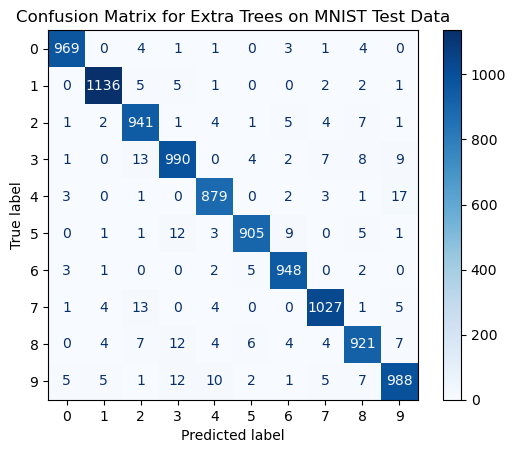

In [63]:
et_cm_display = ConfusionMatrixDisplay(confusion_matrix=et_matrix, display_labels=np.arange(10))
et_cm_display.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix for Extra Trees on MNIST Test Data")
plt.show()

### Produktionssättning av modell

Jag har valt att spara både Extra Trees och CNN för att testa dem med min Streamlit app.  

In [68]:
#train Extra Trees on full data set

et_full = ExtraTreesClassifier(
    n_estimators=400,
    n_jobs=4,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1)


extra_trees_pipeline = make_pipeline(StandardScaler(), et_full)

extra_trees_pipeline.fit(X, y)

#joblib.dump(scaler_full, "../models/scaler_full_v2.pkl")
joblib.dump(extra_trees_pipeline, "../models/extra_trees_mnist_pipeline_v1.pkl") 

['../models/extra_trees_mnist_pipeline_v1.pkl']

In [ ]:
joblib.dump(cnn, '../models/cnn_mnist_model.pkl')

['cnn_mnist_model.pkl']

### Test med appen

Jag byggde en streamlit app för att testa mina två modeller. Som input har jag använt ett HTML5 canvas element. Jag byggde en streamlit component för detta men tog hjälp av github copilot för att scaffolda upp koden till sjäva canvasen, vilken jag sedan anpassade efter mina behov. Det här sättet att inputa siffror har fördelen att det är enklare att testa med mina egna "handskriva" siffror. Canvasen stödjer både muspekare och touch input.

Anekdotiskt  (efter att ha gjort många test med appen) så är accuracy på den nya datan är sämre än på testsettet. Sannolikt beror detta på olikheter i input datan och datasetet som modellen tränats på, alternativt viss överanpassning i modellen. 

Jag fick båda modellerna att prestera bättre genom att centrera bilderna och skala siffrorna till samma storlek. Båda modellerna var känsliga för siffror som t.ex var uppe i ett hörn. Med justeringarna presterar CNN oftast bra så länge siffrorna inte är vinklade eller har oväntade former, men jag upplever att ExtraTrees fortfarande har svårt med en del siffror. Om det var ett riktigt projekt skulle man kankse kunna få bättre resultat med ett större träningsset, t.ex genom att vinkla och skala bilderna till CNN modellen.
